In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams
import torch
from torch.utils.data import DataLoader, TensorDataset
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')


In [ ]:
data = pd.read_csv("/content/drive/MyDrive/colabdata/train.csv.zip")
data.columns


Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/colabdata/train.csv.zip")

data.drop("id", axis=1, inplace=True)

data.head()


,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [ ]:
texts = data['comment_text']
labels = data.iloc[:, 1:]


In [ ]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42)

test_texts, val_texts, test_labels, val_labels = train_test_split(
    test_texts, test_labels, test_size=0.5, random_state=42)


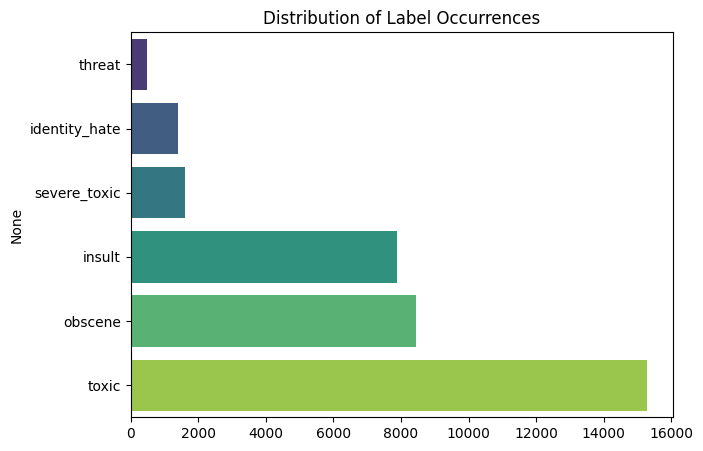

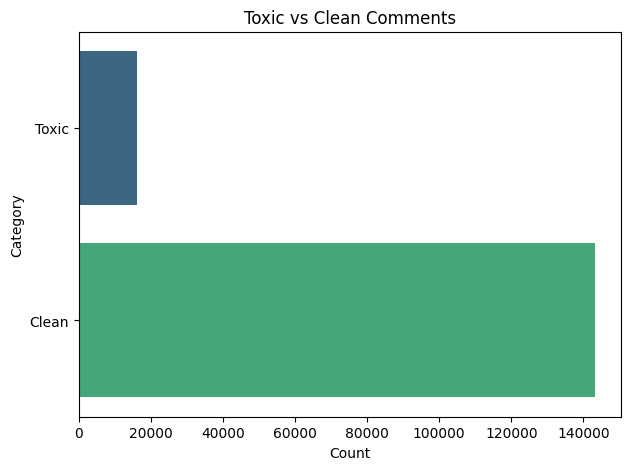

In [ ]:
labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

label_counts = data[labels].sum().sort_values()

plt.figure(figsize=(7, 5))
sns.barplot(x=label_counts.values, y=label_counts.index, palette='viridis')
plt.title('Distribution of Label Occurrences')
plt.show()


# Distribution of Toxic vs Clean Comments
train_toxic = data[data[labels].sum(axis=1) > 0]
train_clean = data[data[labels].sum(axis=1) == 0]

num_toxic = len(train_toxic)
num_clean = len(train_clean)

# Plotting
plot_data = pd.DataFrame({'Category': ['Toxic', 'Clean'], 'Count': [num_toxic, num_clean]})

plt.figure(figsize=(7, 5))
sns.barplot(x='Count', y='Category', data=plot_data, palette='viridis')
plt.title('Toxic vs Clean Comments')
plt.show()



In [ ]:
train_clean_sampled = train_clean.sample(n=9000, random_state=42)
dataframe = pd.concat([train_toxic, train_clean_sampled], axis=0).sample(frac=1, random_state=42)

train_texts, test_texts, train_labels, test_labels = train_test_split(
    dataframe['comment_text'], dataframe.iloc[:, 2:], test_size=0.25, random_state=42)

test_texts, val_texts, test_labels, val_labels = train_test_split(
    test_texts, test_labels, test_size=0.5, random_state=42)



In [ ]:
def tokenize_and_encode(tokenizer, comments, labels, max_length=128):
    input_ids = []
    attention_masks = []

    for comment in comments:
        encoded_dict = tokenizer.encode_plus(
            comment,
            add_special_tokens=True,
            max_length=max_length,
            pad_to_max_length=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        input_ids.append(encoded_dict['input_ids'])
        attention_masks.append(encoded_dict['attention_mask'])

    input_ids = torch.cat(input_ids, dim=0)
    attention_masks = torch.cat(attention_masks, dim=0)
    labels = torch.tensor(labels.values, dtype=torch.float32)

    return input_ids, attention_masks, labels


In [ ]:
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=6)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
input_ids, attention_masks, labels = tokenize_and_encode(tokenizer, train_texts, train_labels)
test_input_ids, test_attention_masks, test_labels = tokenize_and_encode(tokenizer, test_texts, test_labels)
val_input_ids, val_attention_masks, val_labels = tokenize_and_encode(tokenizer, val_texts, val_labels)


Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.


In [ ]:
train_loader = DataLoader(TensorDataset(input_ids, attention_masks, labels), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(test_input_ids, test_attention_masks, test_labels), batch_size=32, shuffle=False)
val_loader = DataLoader(TensorDataset(val_input_ids, val_attention_masks, val_labels), batch_size=32, shuffle=False)


In [ ]:
optimizer = AdamW(model.parameters(), lr=2e-5)


In [ ]:
def train_model(model, train_loader, optimizer, device, num_epochs=1):
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0

        for batch in train_loader:
            input_ids, attention_mask, labels = [t.to(device) for t in batch]

            if labels.shape[1] == 5:
                toxic_column = torch.zeros(labels.shape[0], 1).to(device)
                labels = torch.cat((toxic_column, labels), dim=1)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            total_loss += loss.item()

            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                input_ids, attention_mask, labels = [t.to(device) for t in batch]

                if labels.shape[1] == 5:
                    toxic_column = torch.zeros(labels.shape[0], 1).to(device)
                    labels = torch.cat((toxic_column, labels), dim=1)

                outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
                val_loss += outputs.loss.item()

        print(f'Epoch {epoch+1}, Training Loss: {total_loss/len(train_loader)}, Validation Loss: {val_loss/len(val_loader)}')


from torch.utils.data import DataLoader, TensorDataset

def add_toxic_column(labels):
    if labels.shape[1] == 5:
        toxic_column = torch.zeros(labels.shape[0], 1)
        labels = torch.cat((toxic_column, labels), dim=1)
    return labels

labels_with_toxic = add_toxic_column(labels)

train_loader = DataLoader(TensorDataset(input_ids, attention_masks, labels_with_toxic), batch_size=16, shuffle=True)

train_model(model, train_loader, optimizer, device)

Epoch 1, Training Loss: 0.18717912415755772, Validation Loss: 0.14496753289543016


In [ ]:
def evaluate_model(model, test_loader, device):
    model.eval()
    true_labels = []
    predicted_probs = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids, attention_mask, labels = [t.to(device) for t in batch]

            if labels.shape[1] == 5:
                toxic_column = torch.zeros(labels.shape[0], 1).to(device)
                labels = torch.cat((toxic_column, labels), dim=1)

            outputs = model(input_ids, attention_mask=attention_mask)
            predicted_probs_batch = torch.sigmoid(outputs.logits)

            predicted_probs.append(predicted_probs_batch.cpu().numpy())
            true_labels.append(labels.cpu().numpy())

    true_labels = np.concatenate(true_labels, axis=0)
    predicted_probs = np.concatenate(predicted_probs, axis=0)
    predicted_labels = (predicted_probs > 0.5).astype(int)

    accuracy = accuracy_score(true_labels, predicted_labels)
    precision = precision_score(true_labels, predicted_labels, average='micro')
    recall = recall_score(true_labels, predicted_labels, average='micro')
    f1 = 2 * (precision * recall) / (precision + recall)

    print(f"Accuracy: {accuracy * 100:.2f}%")
    print(f"F1 Score: {f1 * 100:.2f}%")

evaluate_model(model, test_loader, device)



Accuracy: 71.11%
F1 Score: 75.51%
